**###Proyecto final UTEC >>> Daniel Granados Valentin**


In [21]:
#paso 1: Importar librerias necesarias
import pandas as pd                                #Manipulación de datos
import numpy as np                                 #Cálculo numéricos y arreglos
import matplotlib.pyplot as plt                    #Visualización de datos
import seaborn as sns                              #Visualización de datos avanzados
from sklearn.linear_model import LinearRegression  #Modelo de regresión lineal
from google.colab import files                     #Subir archivos desde el navegador

In [22]:
#Paso 2: Subir el archivo excel con los historicos
uploaded = files.upload()                          #Se abre un cuadro para cargar el archivo de excel

Saving ProyectoFinalUTEC_DanielGranados_Dataset.xlsx to ProyectoFinalUTEC_DanielGranados_Dataset (1).xlsx


In [23]:
#Paso 3: Leer el archivo cargado y guardarlo en un DataFrame
df = pd.read_excel("ProyectoFinalUTEC_DanielGranados_Dataset.xlsx")      #cambia el nombre si tu archivo tiene otro

In [24]:
#Paso 4: Mostrar los primeros registros a validar
print("Primeros registros del archivo")
print(df.head())

Primeros registros del archivo
                    Fecha  Empleados_Rotados
0 2025-04-22 00:13:47.653                  1
1 2025-04-23 00:13:47.653                  2
2 2025-04-24 00:13:47.653                  0
3 2025-04-25 00:13:47.653                  0
4 2025-04-26 00:13:47.653                  3


In [25]:
#Paso 5: Agregar columna dias
df['Dias'] = np.arange(len(df))                  #Secuencia 0,1,2

In [26]:
#Paso 6: Definir las variables del modelo
X = df[['Dias']]                                 #Variable independiente en dias
y = df['Empleados_Rotados']                      #Cantidad de empleados que rotaron por dia

In [27]:
#Paso 7: Crear y entrenar el modelo
modelo = LinearRegression()                      #Crear el modelo
modelo.fit(X, y)                                 #Entrenar el modelo

LinearRegression()

In [28]:
#Paso 8: Crear los próximos 30 dias (Como valores X) para predecir
dias_futuros = np.arange(len(df),len(df) + 30).reshape(-1,1) #Matriz de 30 días futuros

In [29]:
#Paso 9: Realizar las predicciones
predicciones = modelo.predict(dias_futuros)     #salida: array de 30 predicciones

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [30]:
#Paso 10: Crear fechas futuras para asignar las predicciones
fechas_futuros = pd.date_range(start=df['Fecha'].iloc[-1] + pd.Timedelta(days=1), periods=30)

In [31]:
#Paso 11: Crear el dataframe con las predicciones y redondearlas a enteros
df_pred = pd.DataFrame({
    'Fecha': fechas_futuros, 'Empleados_Rotados': np.round(predicciones).astype(int)
    })

In [32]:
#Paso 12: Extraer ultimos 30 dias reales
df_real = df.tail(30)[['Fecha','Empleados_Rotados']]
df_real.columns = ['Fecha','Rotacion_Real']

In [33]:
#Paso 13: Combiar datos reales y predichos
df_real.set_index('Fecha', inplace=True)
df_pred.set_index('Fecha', inplace=True)
df_combinado = pd.concat([df_real, df_pred], axis=0)

In [34]:
#Paso 14: Mostrar la tabla en consola
print("\nTabla combinada de datos reales y predichos:")
print(df_combinado.fillna("-"))


Tabla combinada de datos reales y predichos:
                        Rotacion_Real Empleados_Rotados
Fecha                                                  
2025-09-19 00:13:47.653           1.0                 -
2025-09-20 00:13:47.653           2.0                 -
2025-09-21 00:13:47.653           1.0                 -
2025-09-22 00:13:47.653           2.0                 -
2025-09-23 00:13:47.653           1.0                 -
2025-09-24 00:13:47.653           3.0                 -
2025-09-25 00:13:47.653           2.0                 -
2025-09-26 00:13:47.653           1.0                 -
2025-09-27 00:13:47.653           2.0                 -
2025-09-28 00:13:47.653           4.0                 -
2025-09-29 00:13:47.653           1.0                 -
2025-09-30 00:13:47.653           2.0                 -
2025-10-01 00:13:47.653           2.0                 -
2025-10-02 00:13:47.653           1.0                 -
2025-10-03 00:13:47.653           4.0                 -
20

In [35]:
#Paso 15: Exportar la tabla en excel
df_combinado_export = df_combinado.copy()
df_combinado_export.to_excel("Tabla_rotacion_real_vs_prediccion.xlsx")

In [36]:
#Paso 16: Descargar archivo de excel
files.download("Tabla_rotacion_real_vs_prediccion.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

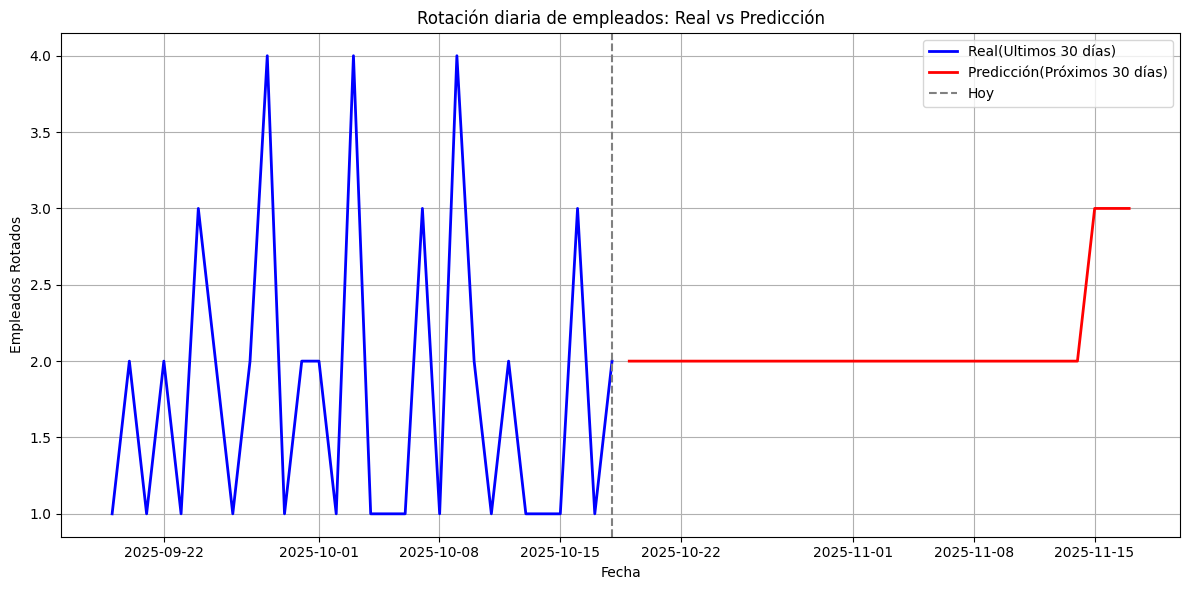

In [37]:
#Paso 17 Graficar los resultado
plt.figure(figsize=(12, 6))
plt.plot(
    df_combinado.index,
    df_combinado['Rotacion_Real'],
    label='Real(Ultimos 30 días)',
    color = 'blue',
    linewidth = 2)
plt.plot(
    df_combinado.index,
    df_combinado['Empleados_Rotados'],
    label='Predicción(Próximos 30 días)',
    color = 'red',
    linewidth = 2)

plt.axvline(x=df_real.index[-1], color='gray', linestyle='--', label='Hoy')

plt.title("Rotación diaria de empleados: Real vs Predicción")
plt.xlabel("Fecha")
plt.ylabel("Empleados Rotados")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()